# AI-Assisted Lease Audit & IFRS 16 Analyser

**Author:** Haagen Lim
**Education:** BCom (Accounting & Commercial Law), University of Auckland
**Focus:** Generative AI for Audit Evidence Extraction & Lease Accounting (IFRS 16)

## Project Overview
This notebook demonstrates an AI-assisted workflow for one of the more error-prone areas of an audit: lease accounting under IFRS 16. Instead of a junior auditor manually reading every contract to extract lease terms, this pipeline uses Claude (Anthropic's LLM) with **structured tool-use output** to extract IFRS 16-relevant fields from contract text, then runs that output through a deterministic Python calculation engine and a rule-based audit-flagging layer.

The goal isn't to replace auditor judgement — it's the opposite: to surface the things that actually need judgement (a borderline renewal option, a related-party lease, a "services agreement" that's secretly a lease) faster and more consistently than a manual first read would, so the auditor's time goes to the judgement calls rather than the data entry.

**Pipeline:**
1. **Sample contracts** — four synthetic lease/services agreements covering a clean baseline case and three deliberately tricky judgement cases
2. **AI extraction** — Claude reads each contract and returns structured JSON via forced tool-use (not free text)
3. **IFRS 16 measurement** — Python calculates the initial lease liability, right-of-use (ROU) asset, and full amortisation schedule
4. **Audit flags** — deterministic rules surface related-party risk, judgement-heavy options, and possible unrecognised (embedded) leases
5. **Consolidated summary** — a cross-contract audit risk view


In [6]:
!pip install anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 956.9/956.9 kB 37.6 MB/s eta 0:00:00


In [7]:
import json
import getpass
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 80)


## Phase 1 — Sample Lease Contracts

Real client contracts obviously can't be used in a public portfolio piece, so these four are synthetic — but each one is built to test a specific IFRS 16 judgement area an auditor would actually encounter:

| Contract | Scenario | What it tests |
|---|---|---|
| A | Straightforward office lease | Clean baseline — no judgement traps |
| B | Warehouse lease with a renewal option | "Reasonably certain to exercise" judgement (significant leasehold improvements) |
| C | Related-party equipment lease, CPI-linked, bargain purchase option | Related-party pricing + bargain purchase + index-linked payment measurement |
| D | "Managed print services" agreement | **Embedded lease** hiding inside a contract not labelled as a lease at all |


In [8]:
CONTRACTS = {
    "A_office_lease": """LEASE AGREEMENT

This Lease Agreement ("Agreement") is made on 1 March 2025 between:

LESSOR: Beachfront Properties Ltd (NZBN: 9429041234567), an unrelated commercial landlord.
LESSEE: Northgate Trading Limited ("the Company")

PREMISES: Level 4, 88 Customs Street, Auckland CBD — approximately 420 square metres of office space.

1. TERM
The lease commences on 1 April 2025 and continues for a non-cancellable period of 5 years (60 months), expiring 31 March 2030. There are no renewal options attached to this lease.

2. RENT
Base rent is fixed at NZD 18,000 per month, payable in advance on the first business day of each month. There is no rent review or escalation clause during the term; rent remains flat for the full 60 months.

3. INCENTIVES
The Lessor has agreed to a rent-free period of one (1) month at lease commencement (April 2025) as a leasing incentive.

4. SECURITY
The Lessee shall provide a bank guarantee equivalent to three (3) months' rent.

5. TERMINATION
Neither party may terminate this lease prior to expiry except for material breach. There is no early termination option available to the Lessee.

6. OUTGOINGS
The Lessee is responsible for its share of building outgoings (rates, insurance, common area maintenance), separately invoiced and not included in the base rent figure above.

7. RELATED PARTY
The Lessor and Lessee confirm they are not related parties and this lease was negotiated on arm's length commercial terms.

8. DISCOUNT RATE / FINANCING
No financing rate is specified in this agreement, as is standard for an operating lease of this nature.

Signed for and on behalf of both parties.
""",
    "B_warehouse_renewal": """DEED OF LEASE

PARTIES:
LESSOR: South Pacific Industrial Estates Ltd
LESSEE: Harlow Distribution Co. Ltd ("the Company")

PREMISES: Warehouse and yard, 14 Wiri Station Road, Manukau, Auckland — 2,100 sqm warehouse plus 600 sqm hardstand yard, fitted with the Company's custom racking and a temperature-controlled cold-store section installed by the Lessee at a cost of NZD 340,000.

1. TERM
Initial non-cancellable term: 1 July 2025 to 30 June 2030 (5 years).

2. RENEWAL OPTION
The Lessee has one option to renew for a further 5 years (1 July 2030 to 30 June 2035), exercisable by written notice to the Lessor no later than 6 months before expiry of the initial term. The renewal rent shall be reset to market rate as determined by an independent valuer, but in any event shall not exceed CPI-adjusted rent from the prior period plus 2%.

Note: the Lessee has invested significantly in custom racking and a temperature-controlled cold-store (NZD 340,000), which is not easily relocated and has a useful economic life of approximately 12 years. Relocating the cold-store facility to alternative premises would cost an estimated NZD 180,000–220,000.

3. RENT
Initial base rent: NZD 31,500 per month, fixed for the first 3 years, then subject to a fixed 3% per annum increase in years 4 and 5.

4. TERMINATION OPTION
No early termination option is available to the Lessee during the initial 5-year term.

5. RELATED PARTY
The Lessor and Lessee are not related parties.

6. DISCOUNT RATE
The agreement does not specify a discount or interest rate. No incremental borrowing rate is stated.

7. OTHER
The Lessee bears all maintenance, insurance and rates costs (triple net lease).
""",
    "C_related_party_cpi": """EQUIPMENT LEASE AGREEMENT

LESSOR: Lim Family Holdings Ltd
LESSEE: Northgate Trading Limited ("the Company")

Note: The Lessor, Lim Family Holdings Ltd, is owned by the spouse of the Company's Managing Director. This is a related-party arrangement.

ASSET: Three (3) forklift units, Model FX-200, serial numbers FX-2201/2202/2203, identified and dedicated to the Company for the lease term (the Lessor has no right to substitute these specific units).

1. TERM
Commencement: 1 January 2025. Non-cancellable term of 4 years, expiring 31 December 2028.

2. PAYMENTS
Base payment: NZD 4,200 per month. Payments are adjusted annually each 1 January in line with the NZ Consumers Price Index (CPI) published by Statistics New Zealand, with a minimum floor adjustment of 0% (i.e. payments cannot decrease even if CPI is negative).

3. PURCHASE OPTION
The Lessee has an option to purchase the three forklift units at the end of the term for NZD 1 each (a nominal/bargain purchase price), significantly below the expected fair value of the units at that time (estimated residual value NZD 8,000–10,000 each based on manufacturer depreciation schedules).

4. RENEWAL/TERMINATION
No renewal option. No early termination right.

5. DISCOUNT RATE
The Lessor's implicit financing rate for this arrangement is 7.5% per annum, as stated in Schedule 2 of this agreement.

6. MAINTENANCE
The Lessee is responsible for all servicing and maintenance of the units during the lease term.
""",
    "D_embedded_lease": """MANAGED PRINT & DOCUMENT SERVICES AGREEMENT

SERVICE PROVIDER: PrintFlow Solutions Ltd
CUSTOMER: Northgate Trading Limited ("the Company")

1. SCOPE OF SERVICES
PrintFlow Solutions Ltd ("the Provider") agrees to supply, install and maintain print and copy equipment at the Company's Auckland office for the purpose of providing document output services.

2. EQUIPMENT
The Provider will install three (3) specific multifunction printer/copier units, Model RX-9000, asset tags PF-1190, PF-1191 and PF-1192, at the Company's premises. These specific units, once installed, are not removed, relocated, or substituted by the Provider during the term of this Agreement except in the event of mechanical failure beyond repair. The Company has the right to determine how, when and for what purpose the units are used, including print volume, paper stock, and operating hours, and the Provider has no right of access to the units except for scheduled servicing visits agreed in advance with the Company.

3. TERM
This Agreement runs for 3 years from 1 September 2024 to 31 August 2027, automatically renewing for successive 1-year periods unless either party gives 90 days' notice of non-renewal.

4. FEES
Monthly service fee: NZD 2,800, which includes equipment provision, all servicing, toner, and parts. This fee is a fixed monthly amount irrespective of print volume (i.e. it is not a pure consumption-based/usage charge).

5. EXCLUSIVITY
The Company may not engage an alternative print services provider for the units covered under this Agreement during its term.

6. TERMINATION
Early termination by the Company prior to the 3-year term requires payment of an exit fee equal to 50% of the remaining fixed monthly fees.

7. NATURE OF AGREEMENT
The parties acknowledge this Agreement is structured as a managed services arrangement and is not described by either party as a lease.
""",
}

print(CONTRACTS["D_embedded_lease"])  # the trickiest one - worth reading in full


MANAGED PRINT & DOCUMENT SERVICES AGREEMENT

SERVICE PROVIDER: PrintFlow Solutions Ltd
CUSTOMER: Northgate Trading Limited ("the Company")

1. SCOPE OF SERVICES
PrintFlow Solutions Ltd ("the Provider") agrees to supply, install and maintain print and copy equipment at the Company's Auckland office for the purpose of providing document output services.

2. EQUIPMENT
The Provider will install three (3) specific multifunction printer/copier units, Model RX-9000, asset tags PF-1190, PF-1191 and PF-1192, at the Company's premises. These specific units, once installed, are not removed, relocated, or substituted by the Provider during the term of this Agreement except in the event of mechanical failure beyond repair. The Company has the right to determine how, when and for what purpose the units are used, including print volume, paper stock, and operating hours, and the Provider has no right of access to the units except for scheduled servicing visits agreed in advance with the Company.

3. T

## Phase 2 — AI Extraction (Claude API)

Rather than asking Claude to "write out the lease terms" in free text and hoping the formatting is parseable, this uses **forced tool-use**: Claude must call a `record_lease_terms` function with a defined JSON schema. This guarantees clean, structured data every time, instead of a sentence I'd have to regex apart.

The system prompt also explicitly tells the model to think like an auditor — apply the "reasonably certain to exercise" test with reasoning, flag contracts that meet the lease definition even if not labelled as one, and say so explicitly when a discount rate isn't stated rather than quietly inventing one.

**A design note on `payment_schedule`, added after real-world testing:** the first version of this schema had the model classify each contract's rent pattern into a category (`flat`, `fixed_percent`, `cpi_linked`) and left the calculation engine to reconstruct the actual payment amounts from that label. That worked for the four synthetic contracts below, but broke down when tested against a real lease pulled from a public SEC filing — a genuine 7-tier rent schedule with a partial floor-area rent abatement in the first two years, a shape that didn't fit any of the three categories. Rather than adding more categories to chase every real-world pattern, the schema now asks Claude to read the actual rent tiers straight off the contract into `payment_schedule` — a direct list of {start month, end month, amount}. This generalises to arbitrary real-world schedules instead of requiring the calculation engine to guess a formula from a label.

**A note on running this notebook:** the cell below needs a live Anthropic API key to call the model. Since this is a public portfolio notebook, `DEMO_MODE` defaults to `True` and uses pre-computed reference extractions (saved further down) instead of spending API credits on every page view. Set `DEMO_MODE = False` and enter your own key to run the live extraction.


In [9]:
MODEL_NAME = "claude-sonnet-4-6"

LEASE_EXTRACTION_TOOL = {
    "name": "record_lease_terms",
    "description": "Record the IFRS 16-relevant terms extracted from a lease or services contract.",
    "input_schema": {
        "type": "object",
        "properties": {
            "lessee": {"type": "string"},
            "lessor": {"type": "string"},
            "related_party": {"type": "boolean"},
            "related_party_rationale": {"type": "string"},
            "commencement_date": {"type": "string", "description": "YYYY-MM-DD"},
            "non_cancellable_term_months": {"type": "integer"},
            "base_payment_monthly": {"type": "number"},
            "payment_escalation_type": {
                "type": "string",
                "enum": ["none", "fixed_percent", "cpi_linked", "other"],
            },
            "payment_escalation_detail": {"type": "string"},
            "payment_schedule": {
                "type": "array",
                "description": (
                    "Every distinct rent tier across the full non-cancellable term, "
                    "read directly from the contract's rent table or escalation "
                    "clause(s) - not inferred from a category label. Tiers must "
                    "fully cover months 1 through non_cancellable_term_months with "
                    "no gaps or overlaps. Reflect rent-free periods or partial "
                    "abatements as their own tier(s) with the actual (possibly "
                    "reduced or zero) amount - do not average them away. For "
                    "payments tied to a future index (e.g. CPI) that is not yet "
                    "known, do NOT forecast future increases: extend the "
                    "commencement-date rate flat for the remaining term instead "
                    "(IFRS 16.27(b))."
                ),
                "items": {
                    "type": "object",
                    "properties": {
                        "start_month": {"type": "integer", "description": "1-indexed, inclusive"},
                        "end_month": {"type": "integer", "description": "1-indexed, inclusive"},
                        "monthly_amount": {"type": "number"},
                    },
                    "required": ["start_month", "end_month", "monthly_amount"],
                },
            },
            "lease_incentive": {"type": "string", "description": "e.g. rent-free period, or 'none'"},
            "renewal_option_months": {"type": "integer", "description": "0 if none"},
            "renewal_reasonably_certain": {
                "type": "string",
                "enum": ["yes", "no", "judgement_required"],
            },
            "renewal_rationale": {"type": "string"},
            "termination_option_exists": {"type": "boolean"},
            "termination_penalty_detail": {"type": "string"},
            "purchase_option_exists": {"type": "boolean"},
            "purchase_option_price": {"type": "number"},
            "purchase_option_is_bargain": {"type": "boolean"},
            "purchase_option_rationale": {"type": "string"},
            "discount_rate_stated": {"type": "number", "description": "-1 if not stated"},
            "identified_asset": {"type": "boolean"},
            "customer_controls_use": {"type": "boolean"},
            "framed_as_service_not_lease": {"type": "boolean"},
            "embedded_lease_likely": {"type": "boolean"},
            "audit_judgement_notes": {
                "type": "string",
                "description": "Plain-English summary of the areas an auditor would need to challenge or follow up on.",
            },
        },
        "required": [
            "lessee", "lessor", "related_party", "commencement_date",
            "non_cancellable_term_months", "base_payment_monthly",
            "payment_escalation_type", "payment_schedule", "renewal_option_months",
            "renewal_reasonably_certain", "termination_option_exists",
            "purchase_option_exists", "discount_rate_stated",
            "identified_asset", "customer_controls_use",
            "embedded_lease_likely", "audit_judgement_notes",
        ],
    },
}

SYSTEM_PROMPT = """You are assisting an audit team by extracting IFRS 16 lease
terms from contracts. You must think like an auditor, not just a clerk:

- Apply IFRS 16's control-based definition of a lease, even if the contract
  is labelled a "services agreement." Check for an identified asset and
  whether the customer controls how, when, and for what purpose it is used.
- For renewal and purchase options, do not just report what the contract
  says - apply the "reasonably certain to exercise" test. Cite the actual
  indicators present in the contract (e.g. significant leasehold
  improvements, bargain purchase price, termination penalties) in your
  rationale. If indicators are mixed or absent, say "judgement_required"
  rather than guessing yes/no.
- Build payment_schedule by reading the contract's actual rent table or
  escalation clause(s) directly - do not infer a generic formula. Cover
  every month of the term with no gaps. If a rent-free period or a partial
  abatement applies, represent it as its own tier at its real amount
  rather than smoothing it into an average. If a payment depends on a
  future index that isn't known yet (e.g. CPI), hold it flat at the
  commencement-date rate rather than forecasting future movements.
- If a discount rate is not stated, say so explicitly rather than inventing
  one - that is a real audit/preparer judgement point, not something to
  silently estimate.
- Flag anything a reviewing auditor would actually query in the
  audit_judgement_notes field, in plain English.

Call the record_lease_terms tool with your findings. Do not respond in free
text."""


def extract_lease_terms(contract_input, client, model=MODEL_NAME):
    """
    Live extraction - requires client = anthropic.Anthropic(api_key=...).

    contract_input can be either:
    - A plain text string (the sample contracts in CONTRACTS above)
    - A file path to a PDF e.g. "my_lease.pdf" (must be in the same folder
      as this notebook)

    The Claude API supports PDFs natively - no separate text extraction
    software needed. Claude reads layout, tables, and structure directly.
    """
    import base64, os

    if isinstance(contract_input, str) and contract_input.strip().lower().endswith(".pdf"):
        # --- PDF path: encode file as base64 and send as a document block ---
        if not os.path.exists(contract_input):
            raise FileNotFoundError(
                f"PDF not found: '{contract_input}'\n"
                f"Make sure the file is in the same folder as this notebook.\n"
                f"In Google Colab: use the folder icon on the left sidebar to upload it."
            )
        with open(contract_input, "rb") as f:
            pdf_data = base64.standard_b64encode(f.read()).decode("utf-8")
        user_content = [
            {
                "type": "document",
                "source": {"type": "base64", "media_type": "application/pdf", "data": pdf_data},
            },
            {"type": "text", "text": "Extract the IFRS 16 lease terms from this contract."},
        ]
    else:
        # --- Plain text: send directly as a string ---
        user_content = f"Extract the lease terms from this contract:\n\n{contract_input}"

    response = client.messages.create(
        model=model,
        max_tokens=1500,
        system=SYSTEM_PROMPT,
        tools=[LEASE_EXTRACTION_TOOL],
        tool_choice={"type": "tool", "name": "record_lease_terms"},
        messages=[{"role": "user", "content": user_content}],
    )
    for block in response.content:
        if block.type == "tool_use" and block.name == "record_lease_terms":
            return block.input
    raise RuntimeError("Model did not return a tool_use block.")


In [10]:
# Reference extractions: produced by applying the exact extraction schema and
# audit logic above by hand to each contract. They exist so this notebook is
# fully demonstrable on GitHub without a reader needing their own API key,
# and so the calculation engine below could be built and validated before
# spending any API credits on live calls.

DEMO_EXTRACTIONS = {
    "A_office_lease": {
        "lessee": "Northgate Trading Limited",
        "lessor": "Beachfront Properties Ltd",
        "related_party": False,
        "related_party_rationale": "Lessor is an unrelated commercial landlord; arm's length terms confirmed.",
        "commencement_date": "2025-04-01",
        "non_cancellable_term_months": 60,
        "base_payment_monthly": 18000,
        "payment_escalation_type": "none",
        "payment_escalation_detail": "Flat rent for full 60-month term, no review clause.",
        "payment_schedule": [
            {"start_month": 1, "end_month": 1, "monthly_amount": 0},
            {"start_month": 2, "end_month": 60, "monthly_amount": 18000},
        ],
        "lease_incentive": "1 month rent-free at commencement (April 2025)",
        "renewal_option_months": 0,
        "renewal_reasonably_certain": "no",
        "renewal_rationale": "No renewal option exists in the contract.",
        "termination_option_exists": False,
        "termination_penalty_detail": "None - no early termination right available.",
        "purchase_option_exists": False,
        "purchase_option_price": -1,
        "purchase_option_is_bargain": False,
        "purchase_option_rationale": "No purchase option in this agreement.",
        "discount_rate_stated": -1,
        "identified_asset": True,
        "customer_controls_use": True,
        "framed_as_service_not_lease": False,
        "embedded_lease_likely": False,
        "audit_judgement_notes": (
            "Clean, low-judgement lease. Only open item is the discount rate: "
            "not stated in the contract, so the lessee's incremental borrowing "
            "rate (IBR) must be estimated and should be independently supportable. "
            "Rent-free month is a lease incentive and should reduce the measured "
            "payment stream in month 1, not be treated as a separate credit."
        ),
    },
    "B_warehouse_renewal": {
        "lessee": "Harlow Distribution Co. Ltd",
        "lessor": "South Pacific Industrial Estates Ltd",
        "related_party": False,
        "related_party_rationale": "No related party indicators present.",
        "commencement_date": "2025-07-01",
        "non_cancellable_term_months": 60,
        "base_payment_monthly": 31500,
        "payment_escalation_type": "fixed_percent",
        "payment_escalation_detail": "Flat for years 1-3, then +3% p.a. in years 4 and 5.",
        "payment_schedule": [
            {"start_month": 1, "end_month": 36, "monthly_amount": 31500},
            {"start_month": 37, "end_month": 48, "monthly_amount": 32445.00},
            {"start_month": 49, "end_month": 60, "monthly_amount": 33418.35},
        ],
        "lease_incentive": "none",
        "renewal_option_months": 60,
        "renewal_reasonably_certain": "judgement_required",
        "renewal_rationale": (
            "IFRS 16 indicators point toward likely exercise: the lessee has "
            "installed NZD 340,000 of custom racking and a cold-store with a "
            "useful life (~12 years) that exceeds the initial 5-year term, and "
            "relocation cost (NZD 180k-220k) is significant relative to "
            "remaining renewal rent. These are textbook 'significant leasehold "
            "improvement' indicators under IFRS 16 application guidance. "
            "However, this is ultimately a management judgement, not a fact - "
            "flagging for auditor challenge rather than asserting yes/no."
        ),
        "termination_option_exists": False,
        "termination_penalty_detail": "None.",
        "purchase_option_exists": False,
        "purchase_option_price": -1,
        "purchase_option_is_bargain": False,
        "purchase_option_rationale": "No purchase option.",
        "discount_rate_stated": -1,
        "identified_asset": True,
        "customer_controls_use": True,
        "framed_as_service_not_lease": False,
        "embedded_lease_likely": False,
        "audit_judgement_notes": (
            "PRIMARY FLAG: renewal option - significant leasehold improvements "
            "suggest renewal is likely, which would extend the lease term to "
            "10 years and materially increase the lease liability. Confirm "
            "whether management's lease term assumption includes the renewal "
            "and whether that's supportable. Discount rate also not stated."
        ),
    },
    "C_related_party_cpi": {
        "lessee": "Northgate Trading Limited",
        "lessor": "Lim Family Holdings Ltd",
        "related_party": True,
        "related_party_rationale": "Lessor is owned by the spouse of the lessee's Managing Director.",
        "commencement_date": "2025-01-01",
        "non_cancellable_term_months": 48,
        "base_payment_monthly": 4200,
        "payment_escalation_type": "cpi_linked",
        "payment_escalation_detail": "Annual CPI adjustment each 1 January, with a 0% floor (cannot decrease).",
        "payment_schedule": [
            {"start_month": 1, "end_month": 48, "monthly_amount": 4200},
        ],
        "lease_incentive": "none",
        "renewal_option_months": 0,
        "renewal_reasonably_certain": "no",
        "renewal_rationale": "No renewal option exists.",
        "termination_option_exists": False,
        "termination_penalty_detail": "None.",
        "purchase_option_exists": True,
        "purchase_option_price": 3,
        "purchase_option_is_bargain": True,
        "purchase_option_rationale": (
            "NZD 1 per unit (x3) against an estimated fair value of "
            "NZD 8,000-10,000 per unit at end of term is a textbook bargain "
            "purchase option - reasonably certain to be exercised."
        ),
        "discount_rate_stated": 7.5,
        "identified_asset": True,
        "customer_controls_use": True,
        "framed_as_service_not_lease": False,
        "embedded_lease_likely": False,
        "audit_judgement_notes": (
            "PRIMARY FLAG: related party - Lessor is controlled by the "
            "Managing Director's spouse. The 7.5% implicit rate and CPI terms "
            "have no independent market comparator in the contract; confirm "
            "arm's-length pricing and related-party disclosure completeness. "
            "SECONDARY: bargain purchase option means ownership transfer is "
            "reasonably certain - the right-of-use asset should be depreciated "
            "over the forklifts' useful life, not the 48-month lease term."
        ),
    },
    "D_embedded_lease": {
        "lessee": "Northgate Trading Limited",
        "lessor": "PrintFlow Solutions Ltd",
        "related_party": False,
        "related_party_rationale": "No related party indicators.",
        "commencement_date": "2024-09-01",
        "non_cancellable_term_months": 36,
        "base_payment_monthly": 2800,
        "payment_escalation_type": "none",
        "payment_escalation_detail": "Fixed monthly fee regardless of print volume - not a pure usage charge.",
        "payment_schedule": [
            {"start_month": 1, "end_month": 36, "monthly_amount": 2800},
        ],
        "lease_incentive": "none",
        "renewal_option_months": 12,
        "renewal_reasonably_certain": "judgement_required",
        "renewal_rationale": (
            "Auto-renews annually unless 90 days' notice of non-renewal is "
            "given, combined with a 50%-of-remaining-fees exit penalty for "
            "early termination. This economic disincentive makes continuation "
            "likely but the evergreen structure needs explicit management "
            "judgement on lease term, not a default assumption."
        ),
        "termination_option_exists": True,
        "termination_penalty_detail": "Exit fee of 50% of remaining fixed monthly fees if terminated early.",
        "purchase_option_exists": False,
        "purchase_option_price": -1,
        "purchase_option_is_bargain": False,
        "purchase_option_rationale": "No purchase option.",
        "discount_rate_stated": -1,
        "identified_asset": True,
        "customer_controls_use": True,
        "framed_as_service_not_lease": True,
        "embedded_lease_likely": True,
        "audit_judgement_notes": (
            "PRIMARY FLAG - COMPLETENESS RISK: despite being labelled a "
            "'Managed Print & Document Services Agreement,' this contract "
            "meets IFRS 16's definition of a lease. Specific serial-numbered "
            "units are identified with no substitution rights (servicing "
            "access does not count as a substitution right), and the customer "
            "(not the provider) decides how, when, and how much the equipment "
            "is used. A fixed fee with no usage-based component reinforces a "
            "lease conclusion. Currently expensed as a pure 'service' cost - "
            "if not already identified and capitalised, this is an "
            "off-balance-sheet lease and a completeness risk in the audit. "
            "The fixed fee bundles equipment and maintenance and would need "
            "to be allocated between lease and non-lease components (or "
            "accounted for entirely as a lease, by accounting policy "
            "election). Discount rate also not stated."
        ),
    },
}


In [11]:
DEMO_MODE = False  # set to False + provide an API key below to run live extraction

if DEMO_MODE:
    extractions = DEMO_EXTRACTIONS
    print("Running in DEMO_MODE - using reference extractions (see note above).")
else:
    import anthropic
    api_key = getpass.getpass("Enter your Anthropic API key: ")
    client = anthropic.Anthropic(api_key=api_key)
    extractions = {cid: extract_lease_terms(text, client) for cid, text in CONTRACTS.items()}
    print("Live extraction complete.")

# The embedded-lease case is the most interesting one to inspect first
print(json.dumps(extractions["D_embedded_lease"], indent=2))


Enter your Anthropic API key: ··········
Live extraction complete.
{
  "lessee": "Northgate Trading Limited",
  "lessor": "PrintFlow Solutions Ltd",
  "related_party": false,
  "commencement_date": "2024-09-01",
  "non_cancellable_term_months": 36,
  "base_payment_monthly": 2800,
  "payment_escalation_type": "none",
  "payment_escalation_detail": "No escalation clause stated. Fixed at NZD 2,800 per month for the full 3-year term.",
  "payment_schedule": [
    {
      "start_month": 1,
      "end_month": 36,
      "monthly_amount": 2800
    }
  ],
  "renewal_option_months": 12,
  "renewal_reasonably_certain": "judgement_required",
  "renewal_rationale": "The contract auto-renews for successive 1-year periods unless 90 days' notice is given. There are no significant leasehold improvements, bargain renewal pricing, or other strong economic incentives cited in the contract that would clearly make renewal reasonably certain. Equally, there is nothing that makes non-renewal clearly more like

## Add Your Own PDF Contracts (optional)

This cell lets you run the exact same pipeline against a real PDF lease — no changes needed anywhere else in the notebook. Everything below (calculations, audit flags, summary table) automatically includes whatever you add here.

**How to upload a PDF in Google Colab:**
1. Click the folder icon in the left sidebar
2. Click the upload icon (page with an up-arrow)
3. Select your PDF — it will appear in the file list
4. Type the exact filename into `PDF_CONTRACTS` below

**Important:** only use contracts you own or have permission to analyse (see note earlier in this notebook about client confidentiality).


In [12]:
# ============================================================
# ADD YOUR OWN PDF CONTRACTS HERE
# ============================================================
# Replace the example below with your actual filename(s).
# The file must be uploaded to the same folder as this notebook.
#
# Format:
#   "short_name_no_spaces": "actual_filename.pdf"
#
# You can add as many as you like, one per line.
# Leave the dict empty (like below) if you have nothing to add yet.

PDF_CONTRACTS = {
    "aaoi_lease": "aaoi_lease.pdf"
}

# ============================================================
# Processing — nothing to change below this line
# ============================================================
if PDF_CONTRACTS:
    # PDFs always need a live API call — DEMO_MODE doesn't apply here
    if "client" not in dir():
        import anthropic
        api_key = getpass.getpass("Enter your Anthropic API key (needed for PDF processing): ")
        client = anthropic.Anthropic(api_key=api_key)

    print(f"Processing {len(PDF_CONTRACTS)} PDF contract(s)...\n")
    for contract_id, pdf_path in PDF_CONTRACTS.items():
        print(f"  Reading: {pdf_path}")
        try:
            extractions[contract_id] = extract_lease_terms(pdf_path, client)
            print(f"  Done — '{contract_id}' added to pipeline.\n")
        except FileNotFoundError as e:
            print(f"  FILE NOT FOUND: {e}\n")
        except Exception as e:
            print(f"  ERROR on {pdf_path}: {e}\n")

    print(f"Total contracts now in pipeline: {len(extractions)}")
    print("Re-run the cells below (Phase 3 onward) to include your PDF results.")
else:
    print("No PDFs added — skipping. Add filenames to PDF_CONTRACTS above when ready.")


Processing 1 PDF contract(s)...

  Reading: aaoi_lease.pdf
  Done — 'aaoi_lease' added to pipeline.

Total contracts now in pipeline: 5
Re-run the cells below (Phase 3 onward) to include your PDF results.


In [13]:
print(list(extractions.keys()))

['A_office_lease', 'B_warehouse_renewal', 'C_related_party_cpi', 'D_embedded_lease', 'aaoi_lease']


In [14]:
import json
print(json.dumps(extractions["aaoi_lease"], indent=2))

{
  "lessee": "Applied Optoelectronics, Inc.",
  "lessor": "Albany Road-Breck Exchange LLC",
  "related_party": false,
  "related_party_rationale": "No indicators of a related-party relationship are present in the contract. The parties are an unaffiliated commercial landlord (Albany Road Real Estate Partners) and a publicly listed technology company (AAOI).",
  "commencement_date": "2025-04-03",
  "non_cancellable_term_months": 84,
  "base_payment_monthly": 31770.83,
  "payment_escalation_type": "fixed_percent",
  "payment_escalation_detail": "Rent escalates on a stepped/fixed basis per the contract's rent table. Each 12-month tier is set at a fixed dollar amount derived from a fixed per-rsf rate applied to either a partial or full rentable area. The steps are not CPI-linked; they are contractually fixed amounts. Approximate step-up rates between tiers are roughly 3% per annum (e.g., $15.25 \u2192 $15.71 \u2192 $16.18 \u2192 $16.66 \u2192 $17.16 \u2192 $17.68 \u2192 $18.21 per rsf). Th

## Phase 3 — IFRS 16 Measurement Engine

This is the part that has to be technically correct, not just plausible-looking. Two design choices worth calling out because they're common sources of error:

1. **Payments in advance (annuity due).** All four contracts specify rent payable in advance, so the first payment is undiscounted in the present value calculation rather than treated as a standard ordinary annuity.
2. **The payment stream is built directly from `payment_schedule`, not reconstructed from a category label.** An earlier version of this engine tried to infer the cash flow from `payment_escalation_type` (flat / a hardcoded +3%-per-year formula / CPI-held-flat) — three buckets that covered the synthetic contracts below but not a real multi-tier rent table encountered during testing (see the note in Phase 2). The engine now just reads the tiers Claude already extracted. The one accounting judgement that still matters: a payment linked to a future index like CPI (Contract C) is initially measured using **the rate as at the commencement date only** — IFRS 16.27(b) and .42 require using the current rate, not a forecast, with remeasurement only when the index actually changes. That rule is now enforced at extraction time (the schedule itself is built flat for index-linked leases) rather than in a separate code branch.

Where a contract doesn't state a discount rate, an incremental borrowing rate (IBR) assumption is applied and clearly labelled as such — this is exactly the kind of number an auditor should be challenging, not accepting silently.


In [15]:
import pandas as pd


# An auditor would never just accept the lessee's number here - flagged
# clearly so it's obvious this is an assumption, not a fact from a contract.
IBR_DEFAULT_ANNUAL = 0.06  # 6.0% p.a. - illustrative incremental borrowing rate


def build_monthly_payments(extraction: dict) -> list:
    """
    Builds the monthly lease payment cash flow directly from the extracted
    payment_schedule - a list of {start_month, end_month, monthly_amount}
    tiers read straight off the contract's actual rent table.

    This replaced an earlier version that tried to infer a payment pattern
    from a category label (flat / fixed_percent / cpi_linked) plus a
    free-text description. That worked for the four synthetic contracts it
    was built around, but broke down on a real lease tested during
    development (a genuine SEC-filed contract with a 7-tier rent schedule
    and a partial floor-area abatement in the first two years) - a shape
    that didn't fit any of the three categories, so the calculator silently
    fell back to a flat rate for the whole term. Having the extraction step
    read off the actual tiers directly, rather than the calculator guessing
    a formula from a label, generalises to arbitrary real-world schedules.

    The index-linked nuance (IFRS 16.27(b): don't forecast future index
    movements) is now handled upstream, at extraction time - the schedule
    the model returns for a CPI-linked lease should already hold the rate
    flat at the commencement-date amount, so no special-casing is needed
    here.
    """
    n = extraction["non_cancellable_term_months"]
    schedule = extraction.get("payment_schedule")

    if not schedule:
        # Defensive fallback only - a well-formed extraction should always
        # include a payment_schedule now that it's a required field.
        base = extraction.get("base_payment_monthly", 0)
        return [base] * n

    payments = [None] * n
    for tier in schedule:
        start = max(1, int(tier["start_month"]))
        end = min(n, int(tier["end_month"]))
        for m in range(start - 1, end):
            payments[m] = tier["monthly_amount"]

    # Defensive gap-fill: real-world contracts are messy, and an extraction
    # occasionally won't perfectly cover every month. Carry the last known
    # rate forward rather than leaving a None that would crash the PV calc.
    last_known = extraction.get("base_payment_monthly", 0)
    for i in range(n):
        if payments[i] is None:
            payments[i] = last_known
        else:
            last_known = payments[i]

    return payments


def pv_of_payments(payments: list, monthly_rate: float) -> float:
    """PV assuming payments in advance (annuity due): first payment undiscounted."""
    return sum(p / ((1 + monthly_rate) ** t) for t, p in enumerate(payments))


def build_amortization_schedule(payments: list, annual_rate: float) -> tuple:
    """Returns (initial_liability, amortization_dataframe)."""
    monthly_rate = annual_rate / 12
    liability_initial = pv_of_payments(payments, monthly_rate)

    rows = []
    balance = liability_initial
    for t, payment in enumerate(payments):
        interest = 0.0 if t == 0 else balance * monthly_rate
        opening = balance + interest
        closing = opening - payment
        rows.append({
            "period": t + 1,
            "opening_liability": round(opening, 2),
            "interest_expense": round(interest, 2),
            "payment": round(payment, 2),
            "closing_liability": round(closing, 2),
        })
        balance = closing

    return round(liability_initial, 2), pd.DataFrame(rows)


def measure_lease(extraction: dict) -> dict:
    """
    Full Phase 3 measurement for one contract: builds cash flows, picks a
    discount rate (stated or default IBR), computes initial lease liability,
    ROU asset, straight-line depreciation, and the full amortization schedule.
    """
    payments = build_monthly_payments(extraction)

    stated_rate = extraction.get("discount_rate_stated", -1)
    rate_used = stated_rate / 100 if stated_rate and stated_rate > 0 else IBR_DEFAULT_ANNUAL
    rate_source = "Stated in contract" if stated_rate and stated_rate > 0 else f"Not stated - IBR assumption of {IBR_DEFAULT_ANNUAL*100:.1f}% applied"

    liability_initial, schedule = build_amortization_schedule(payments, rate_used)
    n_months = extraction["non_cancellable_term_months"]
    rou_initial = liability_initial  # no initial direct costs/restoration costs given
    monthly_depreciation = round(rou_initial / n_months, 2)

    return {
        "lease_liability_initial": liability_initial,
        "rou_asset_initial": rou_initial,
        "discount_rate_used_pct": round(rate_used * 100, 2),
        "discount_rate_source": rate_source,
        "monthly_depreciation": monthly_depreciation,
        "lease_term_months": n_months,
        "amortization_schedule": schedule,
    }


In [16]:
measurements = {cid: measure_lease(ext) for cid, ext in extractions.items()}

for cid, m in measurements.items():
    print(f"{cid}:")
    print(f"  Lease liability (initial): ${m['lease_liability_initial']:,.2f}")
    print(f"  ROU asset (initial):       ${m['rou_asset_initial']:,.2f}")
    print(f"  Discount rate used:        {m['discount_rate_used_pct']}% ({m['discount_rate_source']})")
    print(f"  Monthly depreciation:      ${m['monthly_depreciation']:,.2f}")
    print()


A_office_lease:
  Lease liability (initial): $917,715.39
  ROU asset (initial):       $917,715.39
  Discount rate used:        6.0% (Not stated - IBR assumption of 6.0% applied)
  Monthly depreciation:      $15,295.26

B_warehouse_renewal:
  Lease liability (initial): $1,664,354.60
  ROU asset (initial):       $1,664,354.60
  Discount rate used:        6.0% (Not stated - IBR assumption of 6.0% applied)
  Monthly depreciation:      $27,739.24

C_related_party_cpi:
  Lease liability (initial): $174,790.82
  ROU asset (initial):       $174,790.82
  Discount rate used:        7.5% (Stated in contract)
  Monthly depreciation:      $3,641.48

D_embedded_lease:
  Lease liability (initial): $92,499.04
  ROU asset (initial):       $92,499.04
  Discount rate used:        6.0% (Not stated - IBR assumption of 6.0% applied)
  Monthly depreciation:      $2,569.42

aaoi_lease:
  Lease liability (initial): $3,390,678.72
  ROU asset (initial):       $3,390,678.72
  Discount rate used:        6.0% (Not 

,period,opening_liability,interest_expense,payment,closing_liability
0,1,1664354.60,0.00,31500.0,1632854.60
1,2,1641018.87,8164.27,31500.0,1609518.87
2,3,1617566.47,8047.59,31500.0,1586066.47
3,4,1593996.80,7930.33,31500.0,1562496.80
4,5,1570309.29,7812.48,31500.0,1538809.29
5,6,1546503.33,7694.05,31500.0,1515003.33
6,7,1522578.35,7575.02,31500.0,1491078.35
7,8,1498533.74,7455.39,31500.0,1467033.74


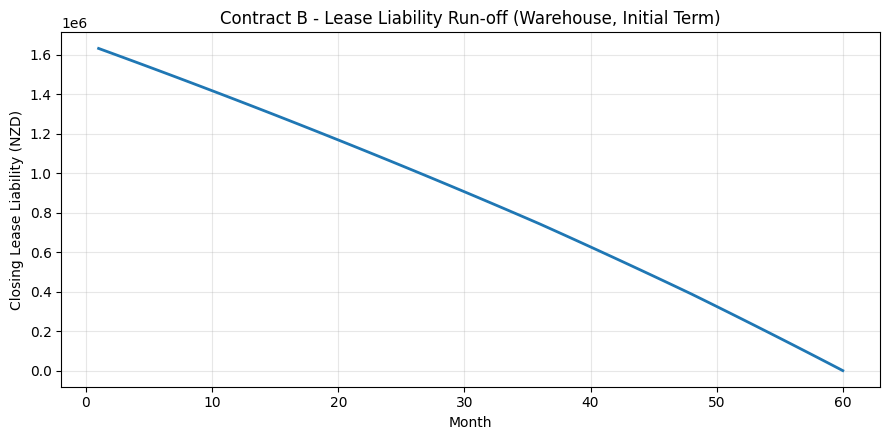

In [17]:
# Closer look: Contract B is the most complex (escalating payments + renewal
# judgement), so its full amortisation schedule and liability run-off are
# worth visualising in detail.
schedule_b = measurements["B_warehouse_renewal"]["amortization_schedule"]
display(schedule_b.head(8))

plt.figure(figsize=(9, 4.5))
plt.plot(schedule_b["period"], schedule_b["closing_liability"], linewidth=2)
plt.title("Contract B - Lease Liability Run-off (Warehouse, Initial Term)")
plt.xlabel("Month")
plt.ylabel("Closing Lease Liability (NZD)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [21]:
print(extractions["aaoi_lease"]["payment_schedule"])
print(measurements["aaoi_lease"]["amortization_schedule"]["payment"].unique())

[{'start_month': 1, 'end_month': 12, 'monthly_amount': 31770.83}, {'start_month': 13, 'end_month': 24, 'monthly_amount': 41893.33}, {'start_month': 25, 'end_month': 36, 'monthly_amount': 52446.12}, {'start_month': 37, 'end_month': 48, 'monthly_amount': 54002.0}, {'start_month': 49, 'end_month': 60, 'monthly_amount': 55622.71}, {'start_month': 61, 'end_month': 72, 'monthly_amount': 57308.25}, {'start_month': 73, 'end_month': 84, 'monthly_amount': 59026.2}]
[31770.83 41893.33 52446.12 54002.   55622.71 57308.25 59026.2 ]


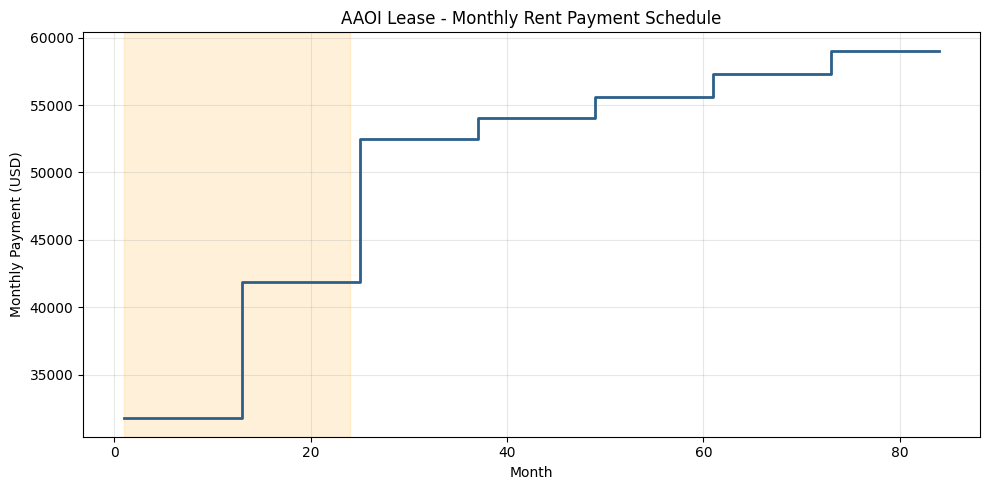

In [22]:
schedule_aaoi = measurements["aaoi_lease"]["amortization_schedule"]

plt.figure(figsize=(10, 5))
plt.step(schedule_aaoi["period"], schedule_aaoi["payment"], where="post", linewidth=2, color="#2c5f8a")
plt.axvspan(1, 24, alpha=0.15, color="orange")
plt.title("AAOI Lease - Monthly Rent Payment Schedule")
plt.xlabel("Month")
plt.ylabel("Monthly Payment (USD)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Phase 4 — Audit Judgement Flags

The flagging logic here is **deliberately rule-based, not another AI call.** In a real audit context, you want a deterministic, explainable reason for every flag — "related party = True triggers this rule" is something you can defend in a working paper; "the AI felt this seemed risky" is not. The AI's job is limited to reading the contract accurately; the audit logic deciding what matters sits in plain Python.


In [18]:
def generate_flags(extraction: dict) -> list:
    flags = []

    if extraction.get("discount_rate_stated", -1) in (-1, None) or extraction.get("discount_rate_stated", -1) <= 0:
        flags.append({
            "severity": "Medium",
            "issue": "Discount rate not stated in contract",
            "detail": "An incremental borrowing rate has been assumed. Confirm this is supportable and consistently applied across similar leases.",
        })

    if extraction.get("related_party"):
        flags.append({
            "severity": "High",
            "issue": "Related party lease",
            "detail": extraction.get("related_party_rationale", "Related party identified - assess arm's length pricing and disclosure completeness."),
        })

    if extraction.get("renewal_reasonably_certain") == "judgement_required":
        flags.append({
            "severity": "High",
            "issue": "Renewal option requires judgement",
            "detail": extraction.get("renewal_rationale", "Renewal option present with no clear-cut exercise conclusion."),
        })

    if extraction.get("purchase_option_is_bargain"):
        flags.append({
            "severity": "Medium",
            "issue": "Bargain purchase option",
            "detail": extraction.get("purchase_option_rationale", "Purchase option priced well below expected fair value - reasonably certain to be exercised."),
        })

    if extraction.get("embedded_lease_likely") or extraction.get("framed_as_service_not_lease"):
        flags.append({
            "severity": "High",
            "issue": "Possible unrecognised embedded lease",
            "detail": "Contract is framed as a service agreement but appears to meet IFRS 16's lease definition (identified asset + customer control over use). Completeness risk if not already capitalised.",
        })

    if extraction.get("payment_escalation_type") == "cpi_linked":
        flags.append({
            "severity": "Low",
            "issue": "Index-linked variable payments",
            "detail": "Confirm initial measurement uses the index/rate as at commencement date only (not a forecast), per IFRS 16.27(b). Remeasure when the index actually changes.",
        })

    schedule = extraction.get("payment_schedule") or []
    if len(schedule) > 2:
        flags.append({
            "severity": "Low",
            "issue": "Multi-tier rent schedule",
            "detail": f"{len(schedule)} distinct rent tiers were extracted. Verify each tier's date range and amount against the source contract's rent table - multi-row schedules are the most error-prone thing to transcribe by hand or by AI.",
        })

    return flags


def flags_to_dataframe(all_flags: dict):
    """all_flags = {contract_id: [flag_dict, ...]} -> tidy DataFrame for display."""
    import pandas as pd
    rows = []
    for contract_id, flags in all_flags.items():
        for f in flags:
            rows.append({"contract": contract_id, **f})
    return pd.DataFrame(rows)


In [19]:
all_flags = {cid: generate_flags(ext) for cid, ext in extractions.items()}
flags_df = flags_to_dataframe(all_flags)
display(flags_df[["contract", "severity", "issue", "detail"]])

print(f"\nTotal flags raised: {len(flags_df)} | High severity: {(flags_df.severity=='High').sum()}")


,contract,severity,issue,detail
0,A_office_lease,Medium,Discount rate not stated in contract,An incremental borrowing rate has been assumed. Confirm this is supportable ...
1,B_warehouse_renewal,Medium,Discount rate not stated in contract,An incremental borrowing rate has been assumed. Confirm this is supportable ...
2,B_warehouse_renewal,Low,Multi-tier rent schedule,3 distinct rent tiers were extracted. Verify each tier's date range and amou...
3,C_related_party_cpi,High,Related party lease,"The Lessor, Lim Family Holdings Ltd, is owned by the spouse of the Company's..."
4,C_related_party_cpi,Medium,Bargain purchase option,"The purchase option price is NZD 1 per unit (NZD 3 total for three units), w..."
5,C_related_party_cpi,Low,Index-linked variable payments,Confirm initial measurement uses the index/rate as at commencement date only...
6,D_embedded_lease,Medium,Discount rate not stated in contract,An incremental borrowing rate has been assumed. Confirm this is supportable ...
7,D_embedded_lease,High,Renewal option requires judgement,The contract auto-renews for successive 1-year periods unless 90 days' notic...
8,D_embedded_lease,High,Possible unrecognised embedded lease,Contract is framed as a service agreement but appears to meet IFRS 16's leas...
9,aaoi_lease,Medium,Discount rate not stated in contract,An incremental borrowing rate has been assumed. Confirm this is supportable ...



Total flags raised: 12 | High severity: 4


## Phase 5 — Consolidated Summary & Audit Takeaways

,Contract,Lessee,Related Party,Term (months),Lease Liability,ROU Asset,Flags (Total / High)
0,A_office_lease,Northgate Trading Limited,False,60,"$917,715","$917,715",1 / 0
1,B_warehouse_renewal,Harlow Distribution Co. Ltd,False,60,"$1,664,355","$1,664,355",2 / 0
2,C_related_party_cpi,Northgate Trading Limited,True,48,"$174,791","$174,791",3 / 1
3,D_embedded_lease,Northgate Trading Limited,False,36,"$92,499","$92,499",3 / 2
4,aaoi_lease,"Applied Optoelectronics, Inc.",False,84,"$3,390,679","$3,390,679",3 / 1


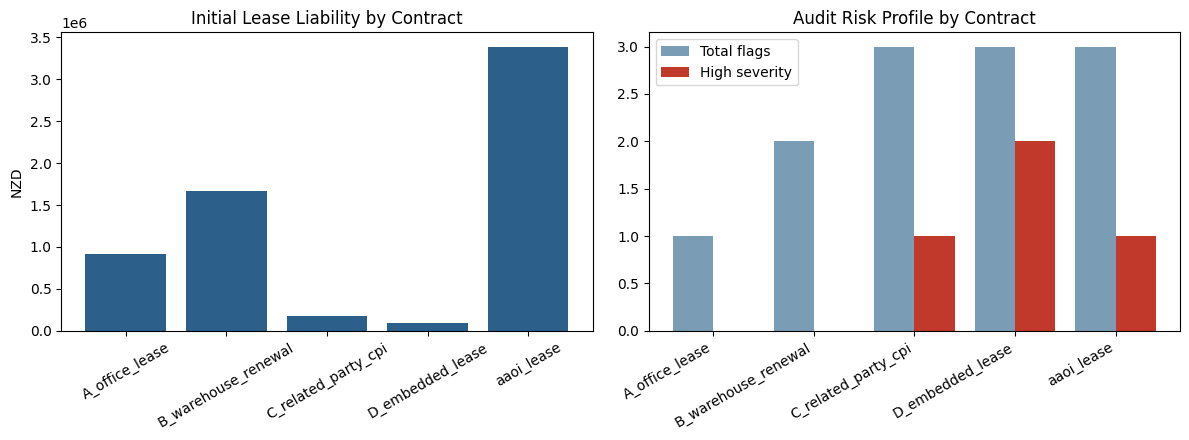

In [20]:
summary_rows = []
for cid, m in measurements.items():
    ext = extractions[cid]
    n_flags = len(all_flags[cid])
    n_high = sum(1 for f in all_flags[cid] if f["severity"] == "High")
    summary_rows.append({
        "Contract": cid,
        "Lessee": ext["lessee"],
        "Related Party": ext["related_party"],
        "Term (months)": m["lease_term_months"],
        "Lease Liability": m["lease_liability_initial"],
        "ROU Asset": m["rou_asset_initial"],
        "Flags (Total / High)": f"{n_flags} / {n_high}",
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.style.format({"Lease Liability": "${:,.0f}", "ROU Asset": "${:,.0f}"}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(summary_df["Contract"], summary_df["Lease Liability"], color="#2c5f8a")
axes[0].set_title("Initial Lease Liability by Contract")
axes[0].set_ylabel("NZD")
axes[0].tick_params(axis='x', rotation=30)

flag_counts = [len(all_flags[cid]) for cid in extractions]
high_counts = [sum(1 for f in all_flags[cid] if f["severity"] == "High") for cid in extractions]
x = np.arange(len(extractions))
axes[1].bar(x - 0.2, flag_counts, width=0.4, label="Total flags", color="#7a9cb5")
axes[1].bar(x + 0.2, high_counts, width=0.4, label="High severity", color="#c0392b")
axes[1].set_xticks(x)
axes[1].set_xticklabels(list(extractions.keys()), rotation=30, ha='right')
axes[1].set_title("Audit Risk Profile by Contract")
axes[1].legend()

plt.tight_layout()
plt.show()


## Key Takeaways

- **The headline finding isn't a number, it's Contract D.** A manual review that only pulled documents tagged "lease" in the contract register would never have looked at a "Managed Print & Document Services Agreement" — yet it meets IFRS 16's lease definition and is currently sitting off-balance-sheet. This is exactly the kind of completeness risk that's hard to catch by sampling and easy to catch by reading *every* contract the same way, which is where AI-assisted extraction earns its place in the workflow.
- **Related-party risk (Contract C)** was flagged automatically because the extraction step explicitly checks for it, not because anyone happened to remember the Managing Director's family connection while skimming a forklift lease.
- **The AI's job was reading, not deciding.** Every judgement call (renewal likelihood, embedded lease conclusion, related-party assessment) is surfaced as a flag with a stated rationale for a human reviewer to challenge — it doesn't unilaterally book a position. That split is intentional: it mirrors how firms are actually being told to deploy this kind of tool, with human review remaining the final control, not a rubber stamp.
- **Stress-testing against a real contract found a real gap, and it was in the calculator, not the AI.** Run against an actual lease from a public SEC filing, the extraction step read the contract's terms correctly — but the calculation engine underneath had only ever been built to handle the three payment patterns present in the four synthetic contracts, and it silently defaulted to a flat rate on a shape it didn't recognise. The fix (Phase 2/3 above) was to have the model read the actual rent tiers directly instead of guessing a formula from a category label. Worth stating plainly: **"the AI is wrong" and "the code around the AI wasn't general enough yet" are different failure modes**, and only checking the final number would have hidden which one this was.
- **Limitations, stated plainly:** the discount rate is an illustrative IBR assumption, not a verified market rate; the calculation engine doesn't yet handle multi-component contracts (e.g. a bundled fee covering both a lease and non-lease services) or formal lease/non-lease component allocation; and this is a portfolio demonstration, not an audit opinion.

---
*Disclaimer: All contracts in this notebook are synthetic and created for portfolio/educational purposes. No real client data was used.*
